In [1]:
from dataclasses import dataclass, field
from pathlib import Path
from typing import Literal, List, Union

from src.utils import get_data_env

from src.dataloading import DeepDataLoader

from src.configmanager._baseconfigmanager import ConfigManager

from src.models import MODELSREGISTRY

from src.models.base.persistencemodel import PersistenceModel
from src.models.deep.gatv2 import GATv2Model
from src.models.deep.gconvlstm import GConvLSTMModel
from src.models.deep.tgcn import TGCNModel

from src.evaluation import Evaluator

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
MODELSREGISTRY = {
        'unknown'               : 0,            # all unknowns will be shown in black
        'PersistenceModel'      : PersistenceModel,
        'NaiveLinearModel'      : 2,
        'SpatioTemporalXGBModel': 3,
        'GATv2Model'            : GATv2Model,
        'TGCNModel'             : TGCNModel,
        'GConvLSTMModel'        : GConvLSTMModel
    }    SpatialGNNModel

In [ ]:
@dataclass
class DataConfig:
    disease_name:       str
    nuts_level:         Literal['nuts1','nuts2','nuts3'] = 'nuts2'
    min_date:           str = '2001-01-01'
    max_date:           str = '2020-06-01'
    split_berlin:       bool = False
    include_population: bool = False
    
@dataclass
class TimeSeriesConfig:
    sequence_length:    int = 12
    horizon_size:       int = 1
    horizon_leadtime:   int = 3
    lags:               int = 1
    
@dataclass
class PreprocessingConfig:
    log_transform_target:   bool = True
    add_time_features:      bool = True
    normalization_method:   Literal['minmax','zscore'] = 'zscore'
    
@dataclass
class SplitConfig:
    split_trainval: str = '2018-06-01'
    split_valtest:  str = '2019-06-01'

@dataclass
class ExperimentConfig:
    name:           str
    data:           DataConfig
    timeseries:     TimeSeriesConfig
    preprocessing:  PreprocessingConfig
    splits:         SplitConfig
    graphs:         Union[List[str], str]
    model:          Union[List[str], str] = 'spatialgcn'
    baseline:       bool                  = True
    global_hparams: dict = field(default_factory=dict)
    model_hparams:  dict = field(default_factory=dict)
    train_hparams:  dict = field(default_factory=dict)

    def __post_init__(self):
        # Normalize model name to lowercase for comparison
        model_name = self.model.lower() if isinstance(self.model, str) else self.model
        
        # Create a case-insensitive lookup
        registry_lower = {k.lower(): k for k in MODELSREGISTRY.keys()}
        
        # Check if model exists in registry (case-insensitive)
        if model_name not in registry_lower:
            available = ', '.join(sorted(MODELSREGISTRY.keys()))
            raise ValueError(
                f"Model '{self.model}' not found in registry. "
                f"Available models: {available}"
            )
        

class ExperimentRunner(ConfigManager):
    """
    Manages configurations of:

    - experiments
    """

    def __init__(self, base_dir: str = "config/experiments/"):
        self.base_dir       = Path(base_dir)
        self.experiment_log = {}
        self.base_dir.mkdir(parents=True, exist_ok=True)

    def define(self, config: ExperimentConfig) -> 'ExperimentRunner':
        """
        Define an experiment using an ExperimentConfig object
        """
        if config.name in self.experiment_log:
            raise KeyError(
                f'An experiment under the name {config.name} has been found in the log. '
                f'Please ensure no double naming.'
            )
        
        self.experiment_log[config.name] = config
        return self

    def execute(self, experiment_name: str):
        """
        Execute an experiment
        """
        if experiment_name not in self.experiment_log:
            raise KeyError(f'No experiment {experiment_name} found in experiment_log')
        
        config = self.experiment_log[experiment_name]

        # Section 1: Get epi-dataloader
        epidata = self._prepare_data(config)

        # Section 2: Get gnn-dataloaders
        gnn_datasets = self._prepare_datasets(epidata, config)
        self.gnn_datasets = gnn_datasets

        # Section 3: run baseline model
        persistence_baseline = PersistenceModel(epidata, name = 'baseline')
        persistence_baseline.forecast('test')

        # Section 3: Models - use registry directly!
        models_dict = {}
        model_name = config.model
        
        # Get the model class from registry
        ModelClass = MODELSREGISTRY[model_name]
        
        for graph, dataset in gnn_datasets.items():
            ml_instance = ModelClass(
                name=f'{graph}',
                dataloader=dataset
            )
            models_dict[graph] = ml_instance  

        # Section 4: Train and evaluate
        for graph, ml_instance in models_dict.items():
            ml_instance.set_model_hparams(**config.model_hparams)
            ml_instance.set_global_hparams(**config.global_hparams)
            # ml_instance.run_snapshot(debug=True)
            ml_instance.train(**config.train_hparams)
            ml_instance.forecast()
            ml_instance.show_forecasts(dataset='test', target_h=0)
            models_dict[graph] = ml_instance
        models_dict['persistence_baseline'] = persistence_baseline
        self.models_dict = models_dict

        self._evaluate()
        

    def _prepare_data(self, config: ExperimentConfig) -> DeepDataLoader:
        """Handle all data loading and preprocessing"""
        epidata = DeepDataLoader(
            disease_name=config.data.disease_name,
            data_env_dir=get_data_env(),
            min_date=config.data.min_date,
            max_date=config.data.max_date,
            nuts_level=config.data.nuts_level,
            include_population=config.data.include_population,
            sequence_length=config.timeseries.sequence_length,
            horizon_size=config.timeseries.horizon_size,
            horizon_leadtime=config.timeseries.horizon_leadtime,
            split_berlin=config.data.split_berlin
        )
        
        if config.preprocessing.add_time_features:
            epidata.add_time_features()
        if config.preprocessing.log_transform_target:
            epidata.log_transform_target()

        epidata.set_splits(
            split_trainval=config.splits.split_trainval,
            split_valtest=config.splits.split_valtest
        )
        
        epidata.normalize(normalization_method=config.preprocessing.normalization_method)
        epidata.add_lagged_features(lags=config.timeseries.lags)
        epidata.finalize()
        
        return epidata

    def _evaluate(self):
        evaluation = Evaluator(list(self.models_dict.values()), horizon_leadtime=self.experiment_log['experiment1'].timeseries.horizon_leadtime)
        evaluation.add_evaluation()
        evaluation.plot_metric('corr',plot_type='box')
        evaluation.plot_metric('ccc',plot_type='box')        

    def _prepare_datasets(self, epidata: DeepDataLoader, config: ExperimentConfig) -> dict:
        """Prepare GNN datasets for all graphs"""
        graphs = config.graphs if isinstance(config.graphs, list) else [config.graphs]
        
        gnn_datasets = {}
        for graph in graphs:
            gnn_datasets[graph] = (
                epidata.copy(deep=True)
                .retrieve_graph(graphname=graph)
                .construct_dataloaders()
            )
        
        return gnn_datasets

/home/de-schrijvers/projects/germany_gnn/src/evaluation/evaluator.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
/home/de-schrijvers/projects/germany_gnn/src/evaluation/evaluator.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


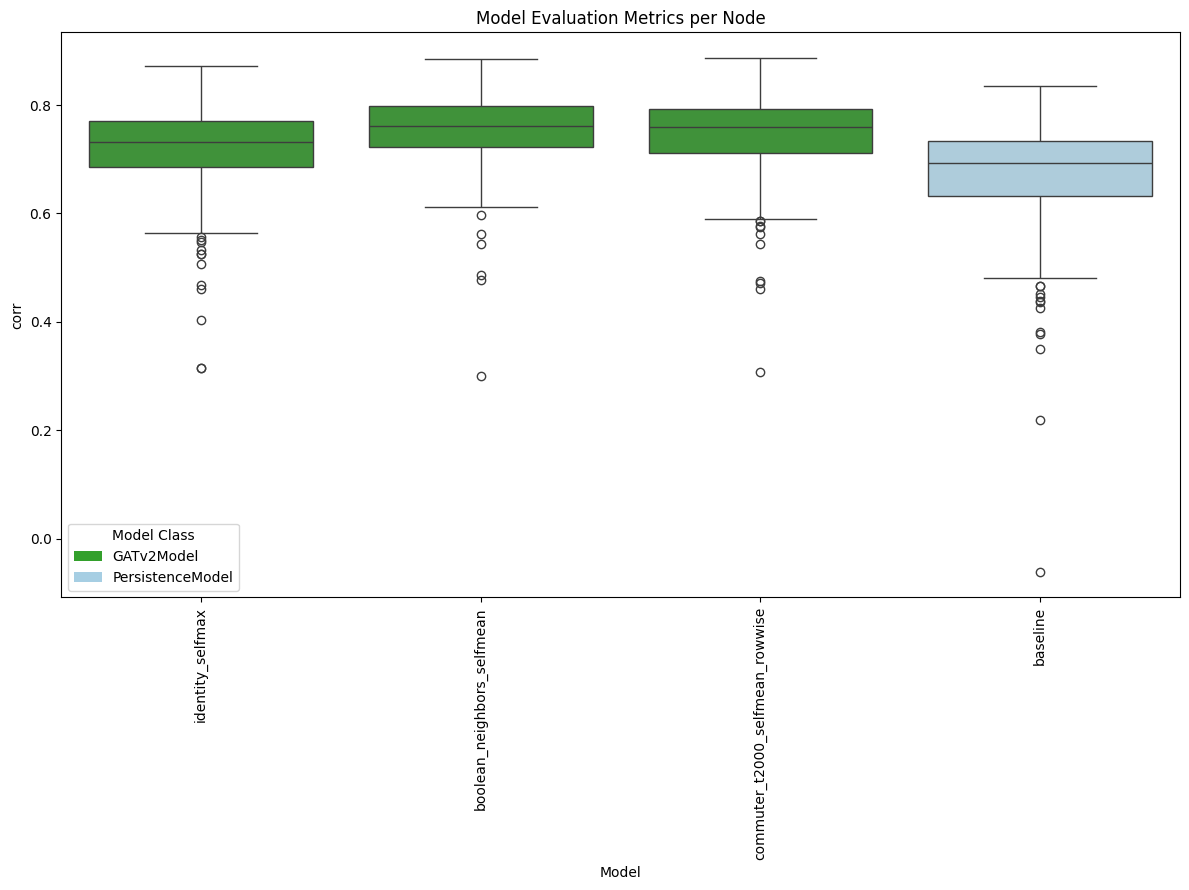

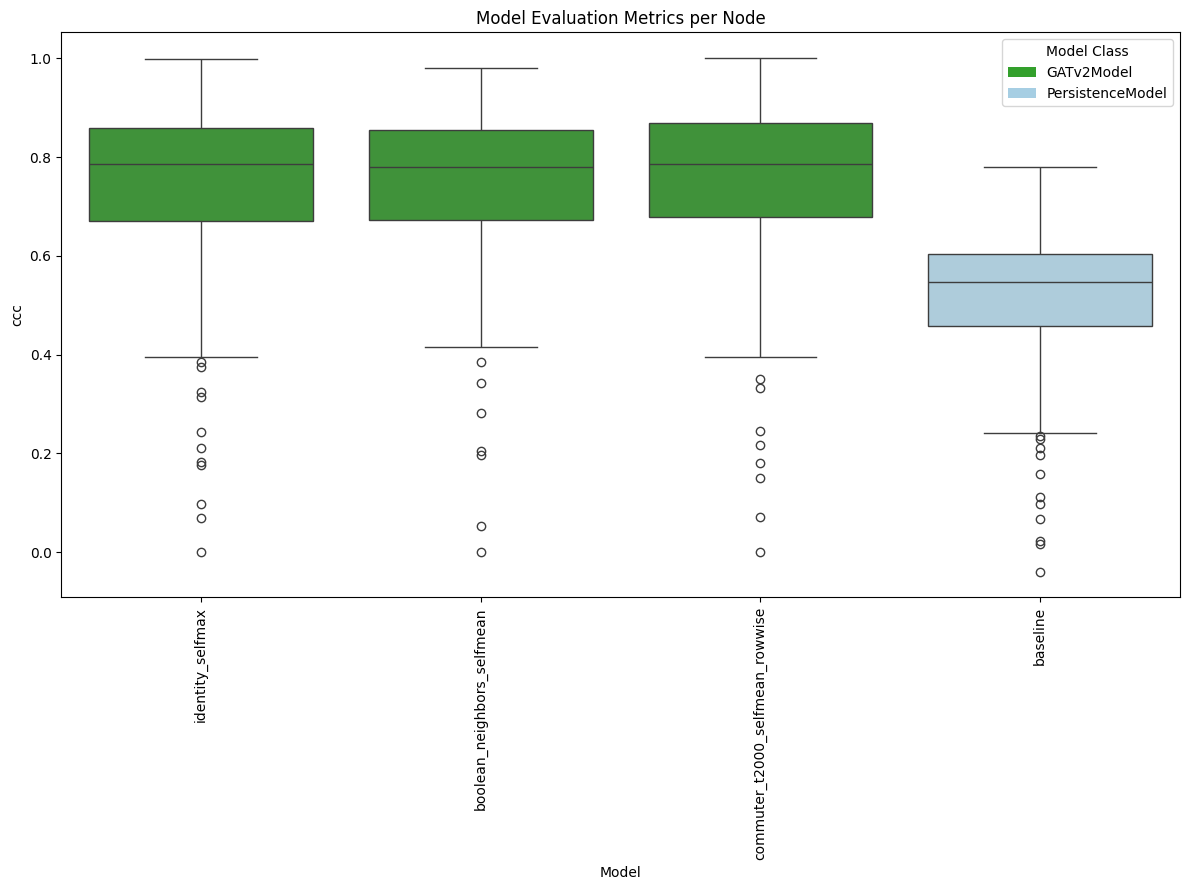

In [ ]:
runner.

In [4]:
# training hparams
n_epochs        = 200
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'


global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.6, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

config = ExperimentConfig(
    name='experiment1',
    data=DataConfig(
        disease_name        = 'influenza',
        nuts_level          = 'nuts3',
        min_date            = '2006-05-15',
        max_date            = '2020-06-01',
        split_berlin        = False,
        include_population  = False

    ),
    timeseries=TimeSeriesConfig(
        sequence_length = 1,
        horizon_size    = 1,
        horizon_leadtime= 3,
        lags            = 1
    ),
    preprocessing=PreprocessingConfig(
        log_transform_target= True,
        add_time_features   = True,
        normalization_method='zscore'
    ),
    splits=SplitConfig(
        split_trainval  = '2018-06-01',
        split_valtest   = '2019-06-01'
    ),
    model='GATv2Model',
    global_hparams = global_hparams,
    train_hparams  = {'verbose':2},
    graphs         = ['identity_selfmax','boolean_neighbors_selfmean','commuter_t2000_selfmean_rowwise'],
    baseline = True
)

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))

==     Training identity_selfmax     ==
Epoch 1 train loss: 0.7182, val loss: 1.1962 ✓ (new best)
Epoch 2 train loss: 0.6727, val loss: 1.0750 ✓ (new best)
Epoch 3 train loss: 0.6493, val loss: 0.9638 ✓ (new best)
Epoch 4 train loss: 0.6360, val loss: 0.8899 ✓ (new best)
Epoch 5 train loss: 0.6243, val loss: 0.8263 ✓ (new best)
Epoch 6 train loss: 0.6179, val loss: 0.7809 ✓ (new best)
Epoch 7 train loss: 0.6055, val loss: 0.7269 ✓ (new best)
Epoch 8 train loss: 0.5991, val loss: 0.6935 ✓ (new best)
Epoch 9 train loss: 0.5928, val loss: 0.6752 ✓ (new best)
Epoch 10 train loss: 0.5896, val loss: 0.6610 ✓ (new best)
Epoch 11 train loss: 0.5845, val loss: 0.6371 ✓ (new best)
Epoch 12 train loss: 0.5775, val loss: 0.6335 ✓ (new best)
Epoch 13 train loss: 0.5775

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 578.64it/s]


Test loss: 0.7933
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))

==     Training boolean_neighbors_selfmean     ==
Epoch 1 train loss: 0.7408, val loss: 1.2030 ✓ (new best)
Epoch 2 train loss: 0.6654, val loss: 1.0092 ✓ (new best)
Epoch 3 train loss: 0.6284, val loss: 0.8856 ✓ (new best)
Epoch 4 train loss: 0.6031, val loss: 0.7984 ✓ (new best)
Epoch 5 train loss: 0.5875, val loss: 0.7370 ✓ (new best)
Epoch 6 train loss: 0.5797, val loss: 0.7056 ✓ (new best)
Epoch 7 train loss: 0.5738, val loss: 0.6885 ✓ (new best)
Epoch 8 train loss: 0.5619, val loss: 0.6717 ✓ (new best)
Epoch 9 train loss: 0.5603, val loss: 0.6688 ✓ (new best)
Epoch 10 train loss: 0.5583, val loss: 0.6659 ✓ (new best)
Epoch 11 train loss: 0.5505, val loss: 0.6602 ✓ (new best)
Epoch 12 train loss: 0.5417, val loss: 0.6577 ✓ (new best)
Epoch 13 train loss: 0.5411, val loss: 0.6575 ✓ (new best)
Epoch 14 train loss: 0.5349, val loss: 0.6615 (patience: 1/20

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 576.64it/s]

Test loss: 0.7237


Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 1754), edge_weight=(1754,))

==     Training commuter_t2000_selfmean_rowwise     ==
Epoch 1 train loss: 0.7294, val loss: 1.2031 ✓ (new best)
Epoch 2 train loss: 0.6587, val loss: 1.0372 ✓ (new best)
Epoch 3 train loss: 0.6259, val loss: 0.9357 ✓ (new best)
Epoch 4 train loss: 0.6113, val loss: 0.8753 ✓ (new best)
Epoch 5 train loss: 0.6003, val loss: 0.8394 ✓ (new best)
Epoch 6 train loss: 0.5897, val loss: 0.8025 ✓ (new best)
Epoch 7 train loss: 0.5798, val loss: 0.7777 ✓ (new best)
Epoch 8 train loss: 0.5792, val loss: 0.7586 ✓ (new best)
Epoch 9 train loss: 0.5715, val loss: 0.7408 ✓ (new best)
Epoch 10 train loss: 0.5670, val loss: 0.7411 (patience: 1/20)
Epoch 11 train loss: 0.5653, val loss: 0.7288 ✓ (new best)
Epoch 12 train loss: 0.5608, val loss: 0.7310 (patience: 1/20)
Epoch 13 train loss: 0.5585, val loss: 0.7263 ✓ (new best)
Epoch 14 train loss: 0.5563, val loss: 0.7265 (patience: 1/20)
Epo

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 569.03it/s]

Test loss: 0.7244


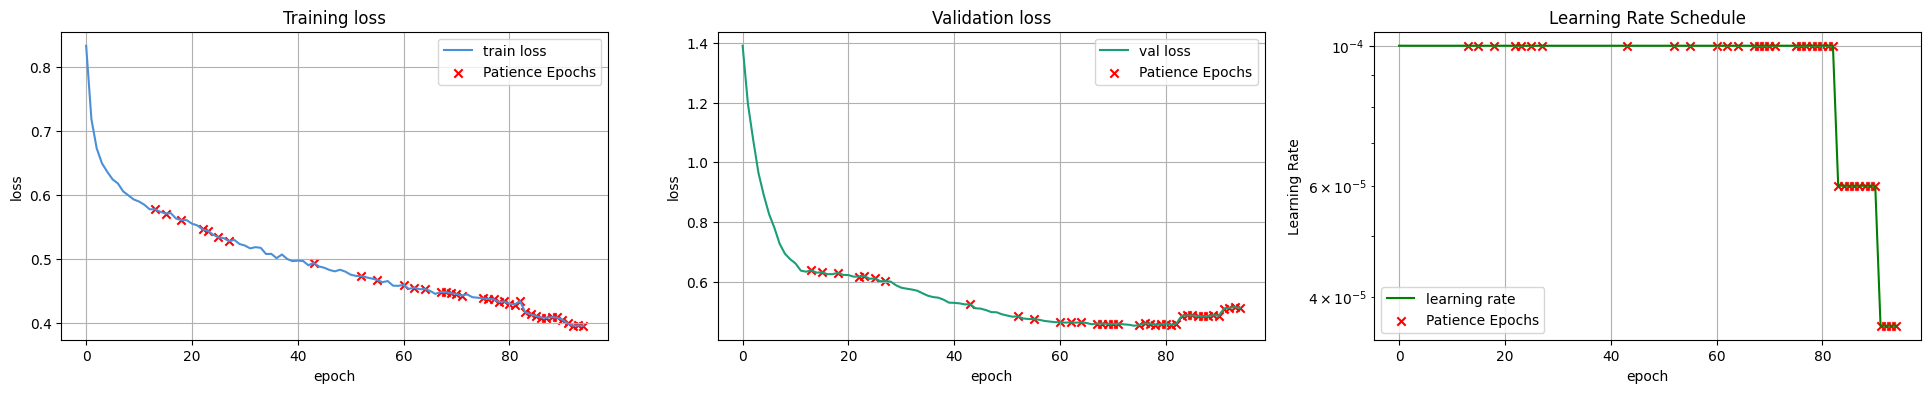

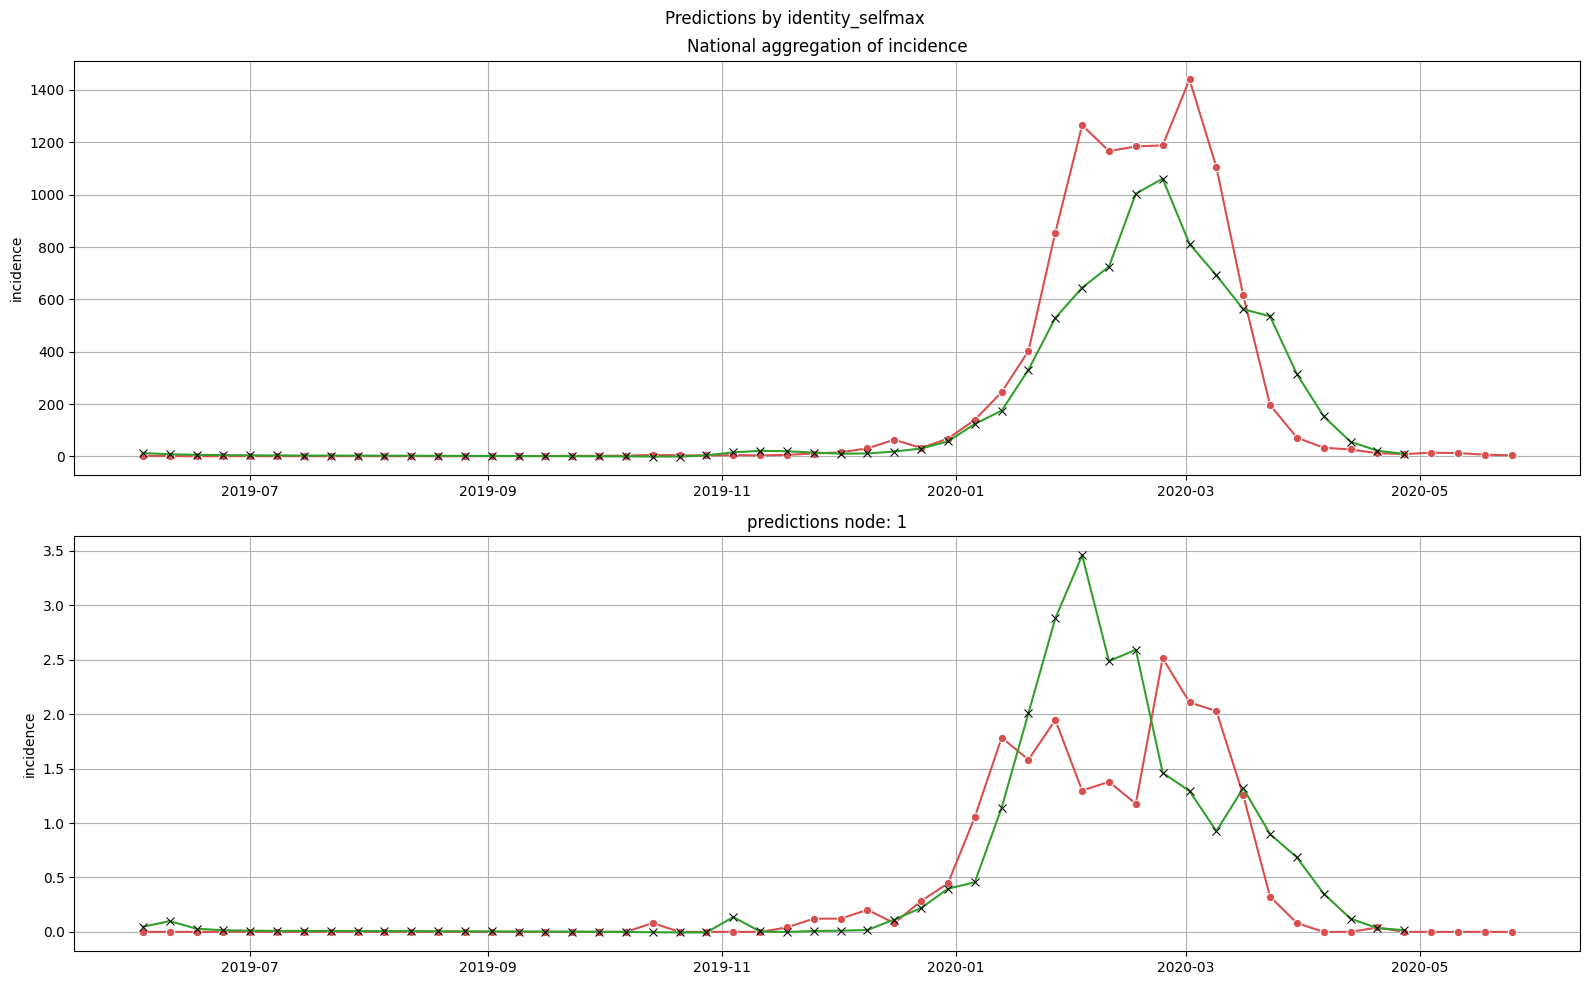

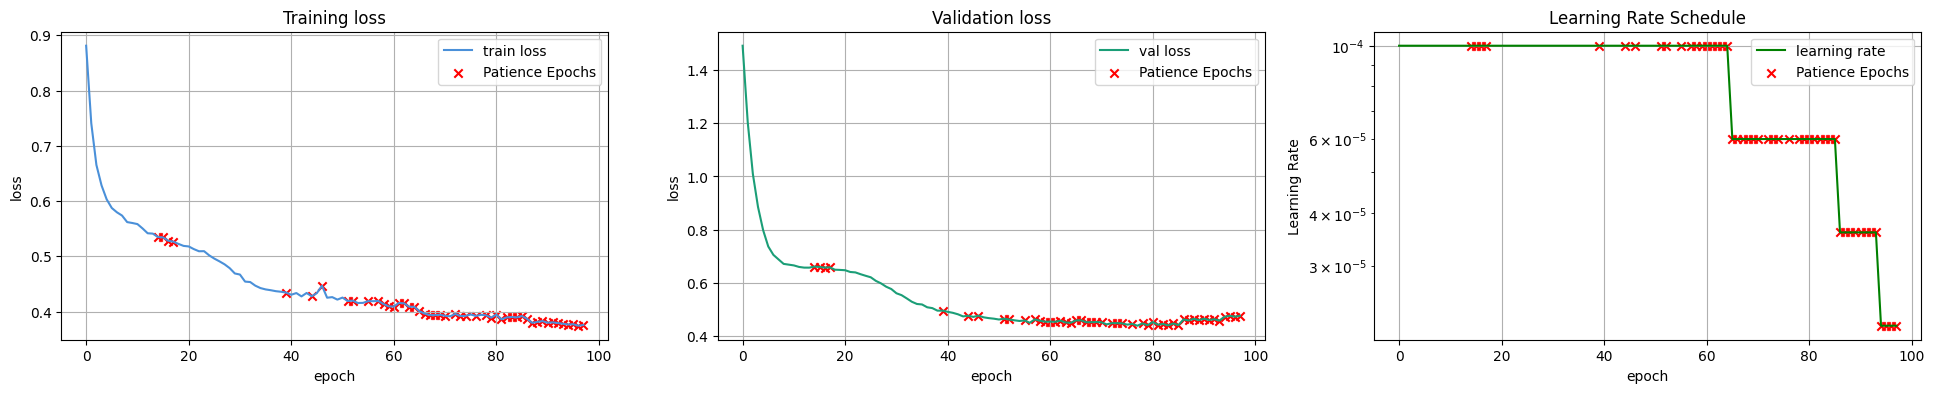

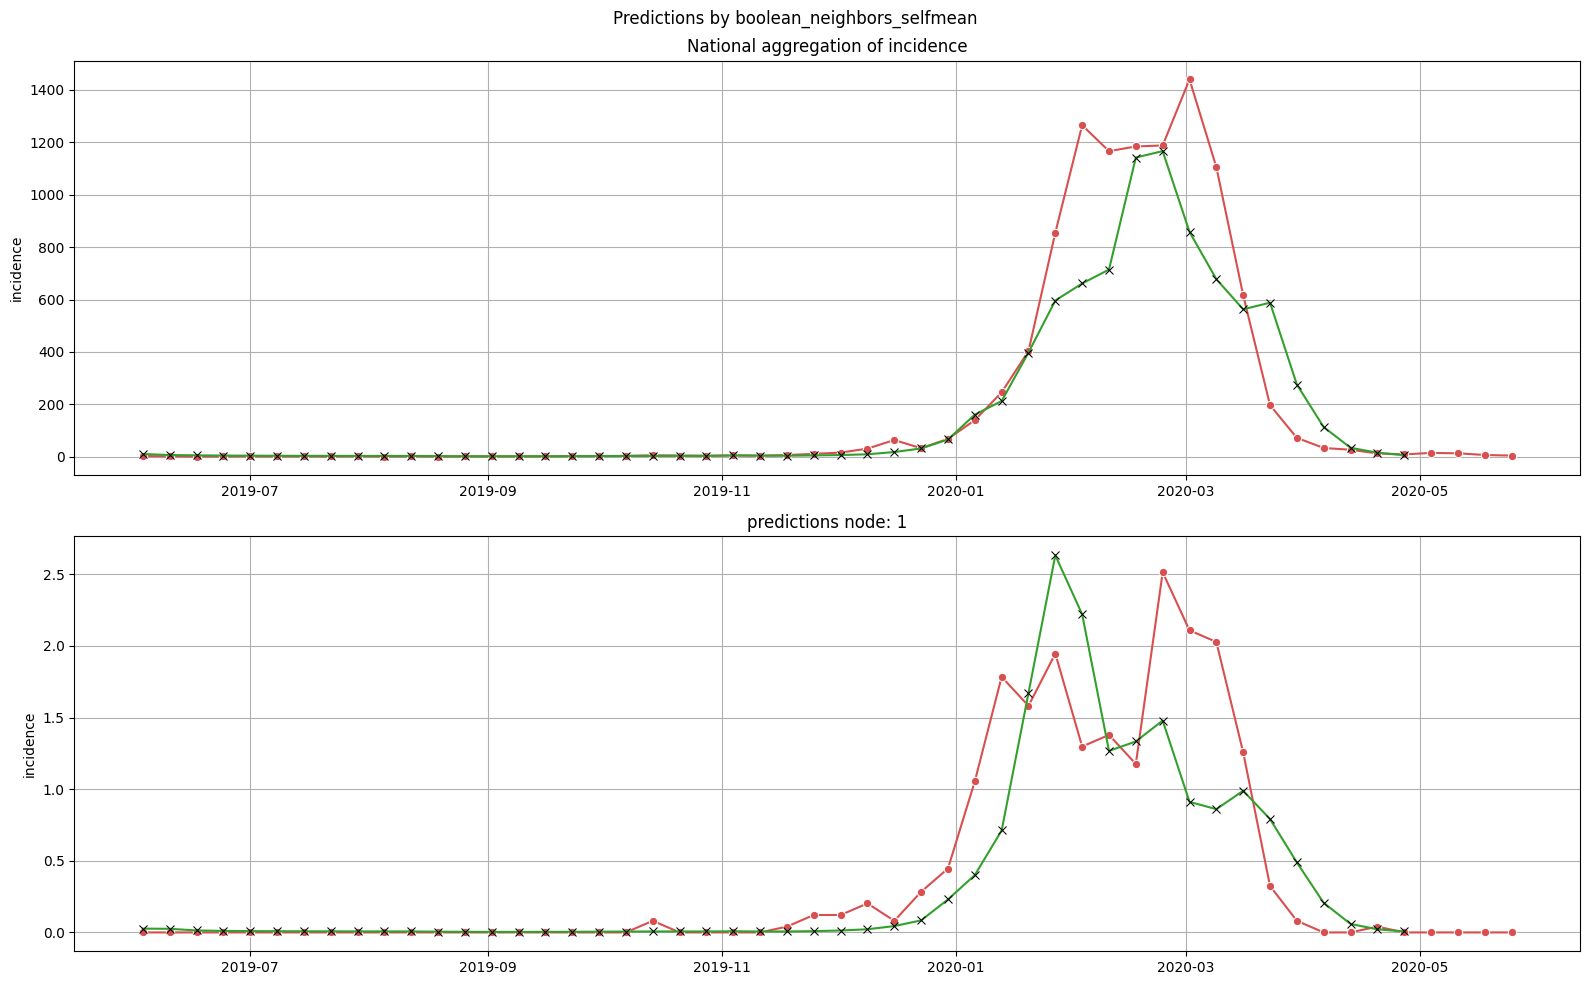

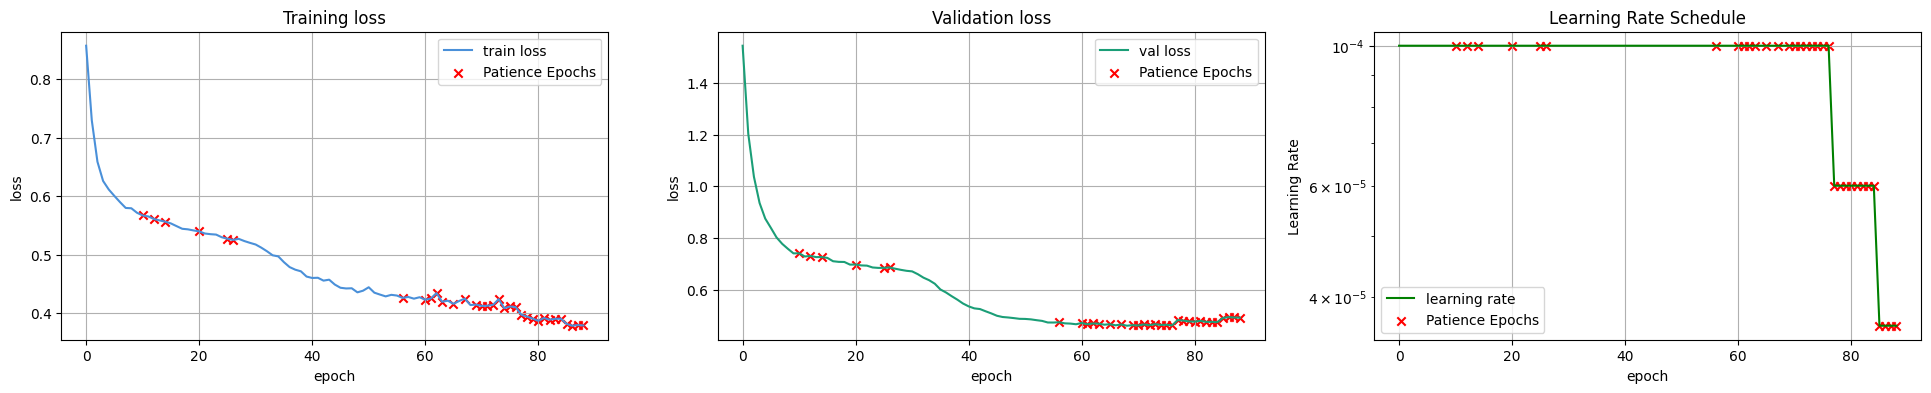

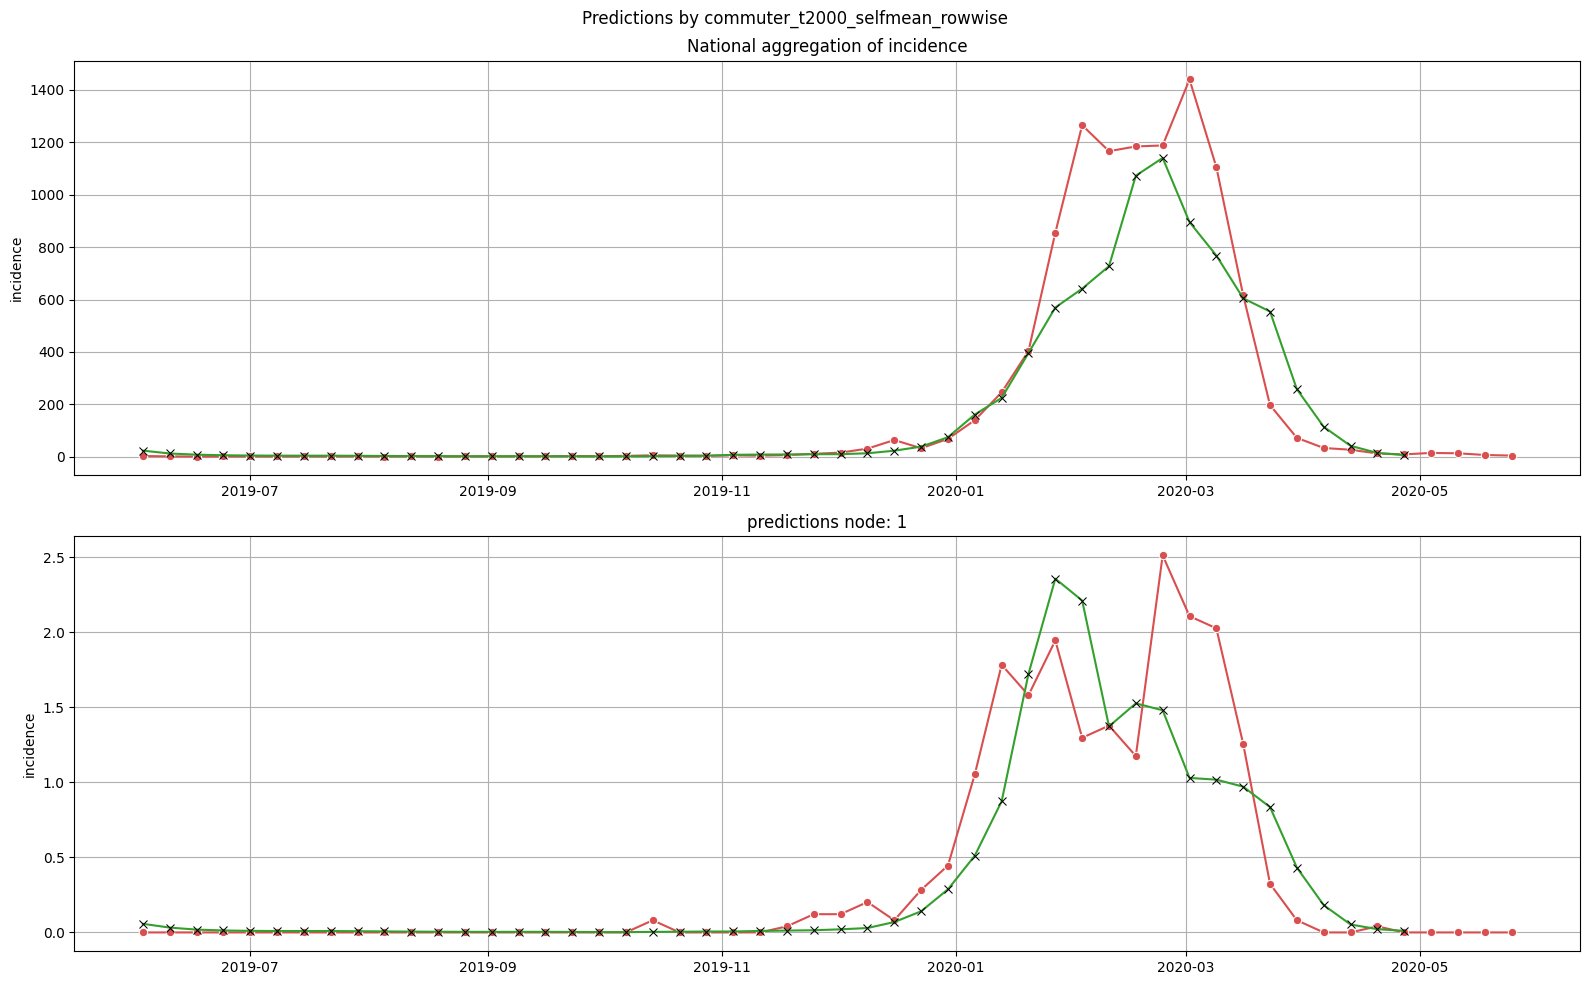

In [5]:
runner = ExperimentRunner()
runner.define(config).execute('experiment1')

In [15]:
commutermodel = runner.models_dict['commuter_t2000_selfmean_rowwise']

commutermodel.forecast('train')



Forecasting train:   0%|                                                                                                                                                              | 0/630 [00:00<?, ?it/s]

Forecasting train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 630/630 [00:01<00:00, 581.71it/s]


Train loss: 0.3376


GATv2Model(name='commuter_t2000_selfmean_rowwise')

EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

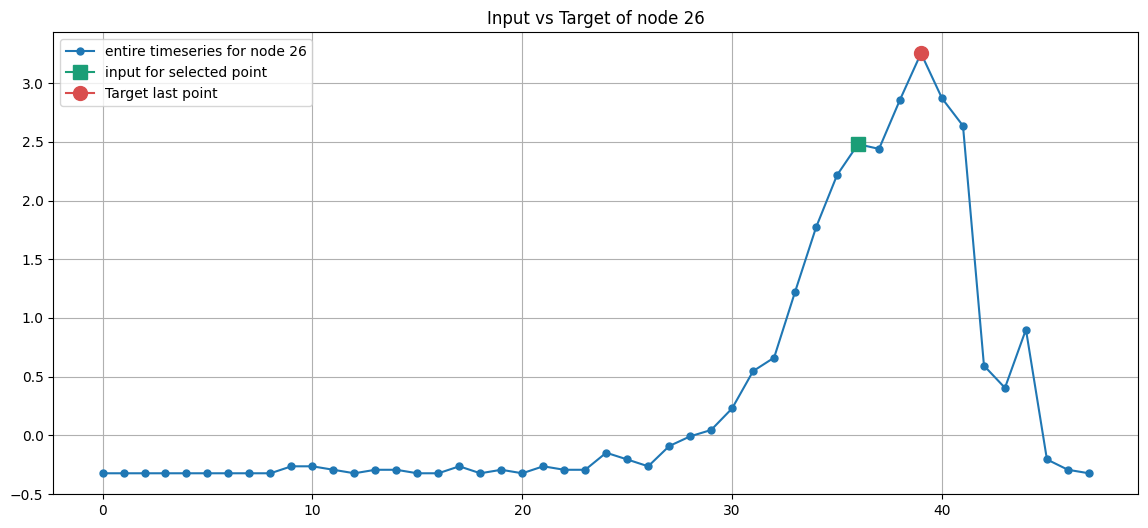

In [44]:
commutermodel.dataloader.preview_dataloader(26,39)

(<Figure size 1600x2000 with 4 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 69'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 223'}, ylabel='incidence'>],
       dtype=object))

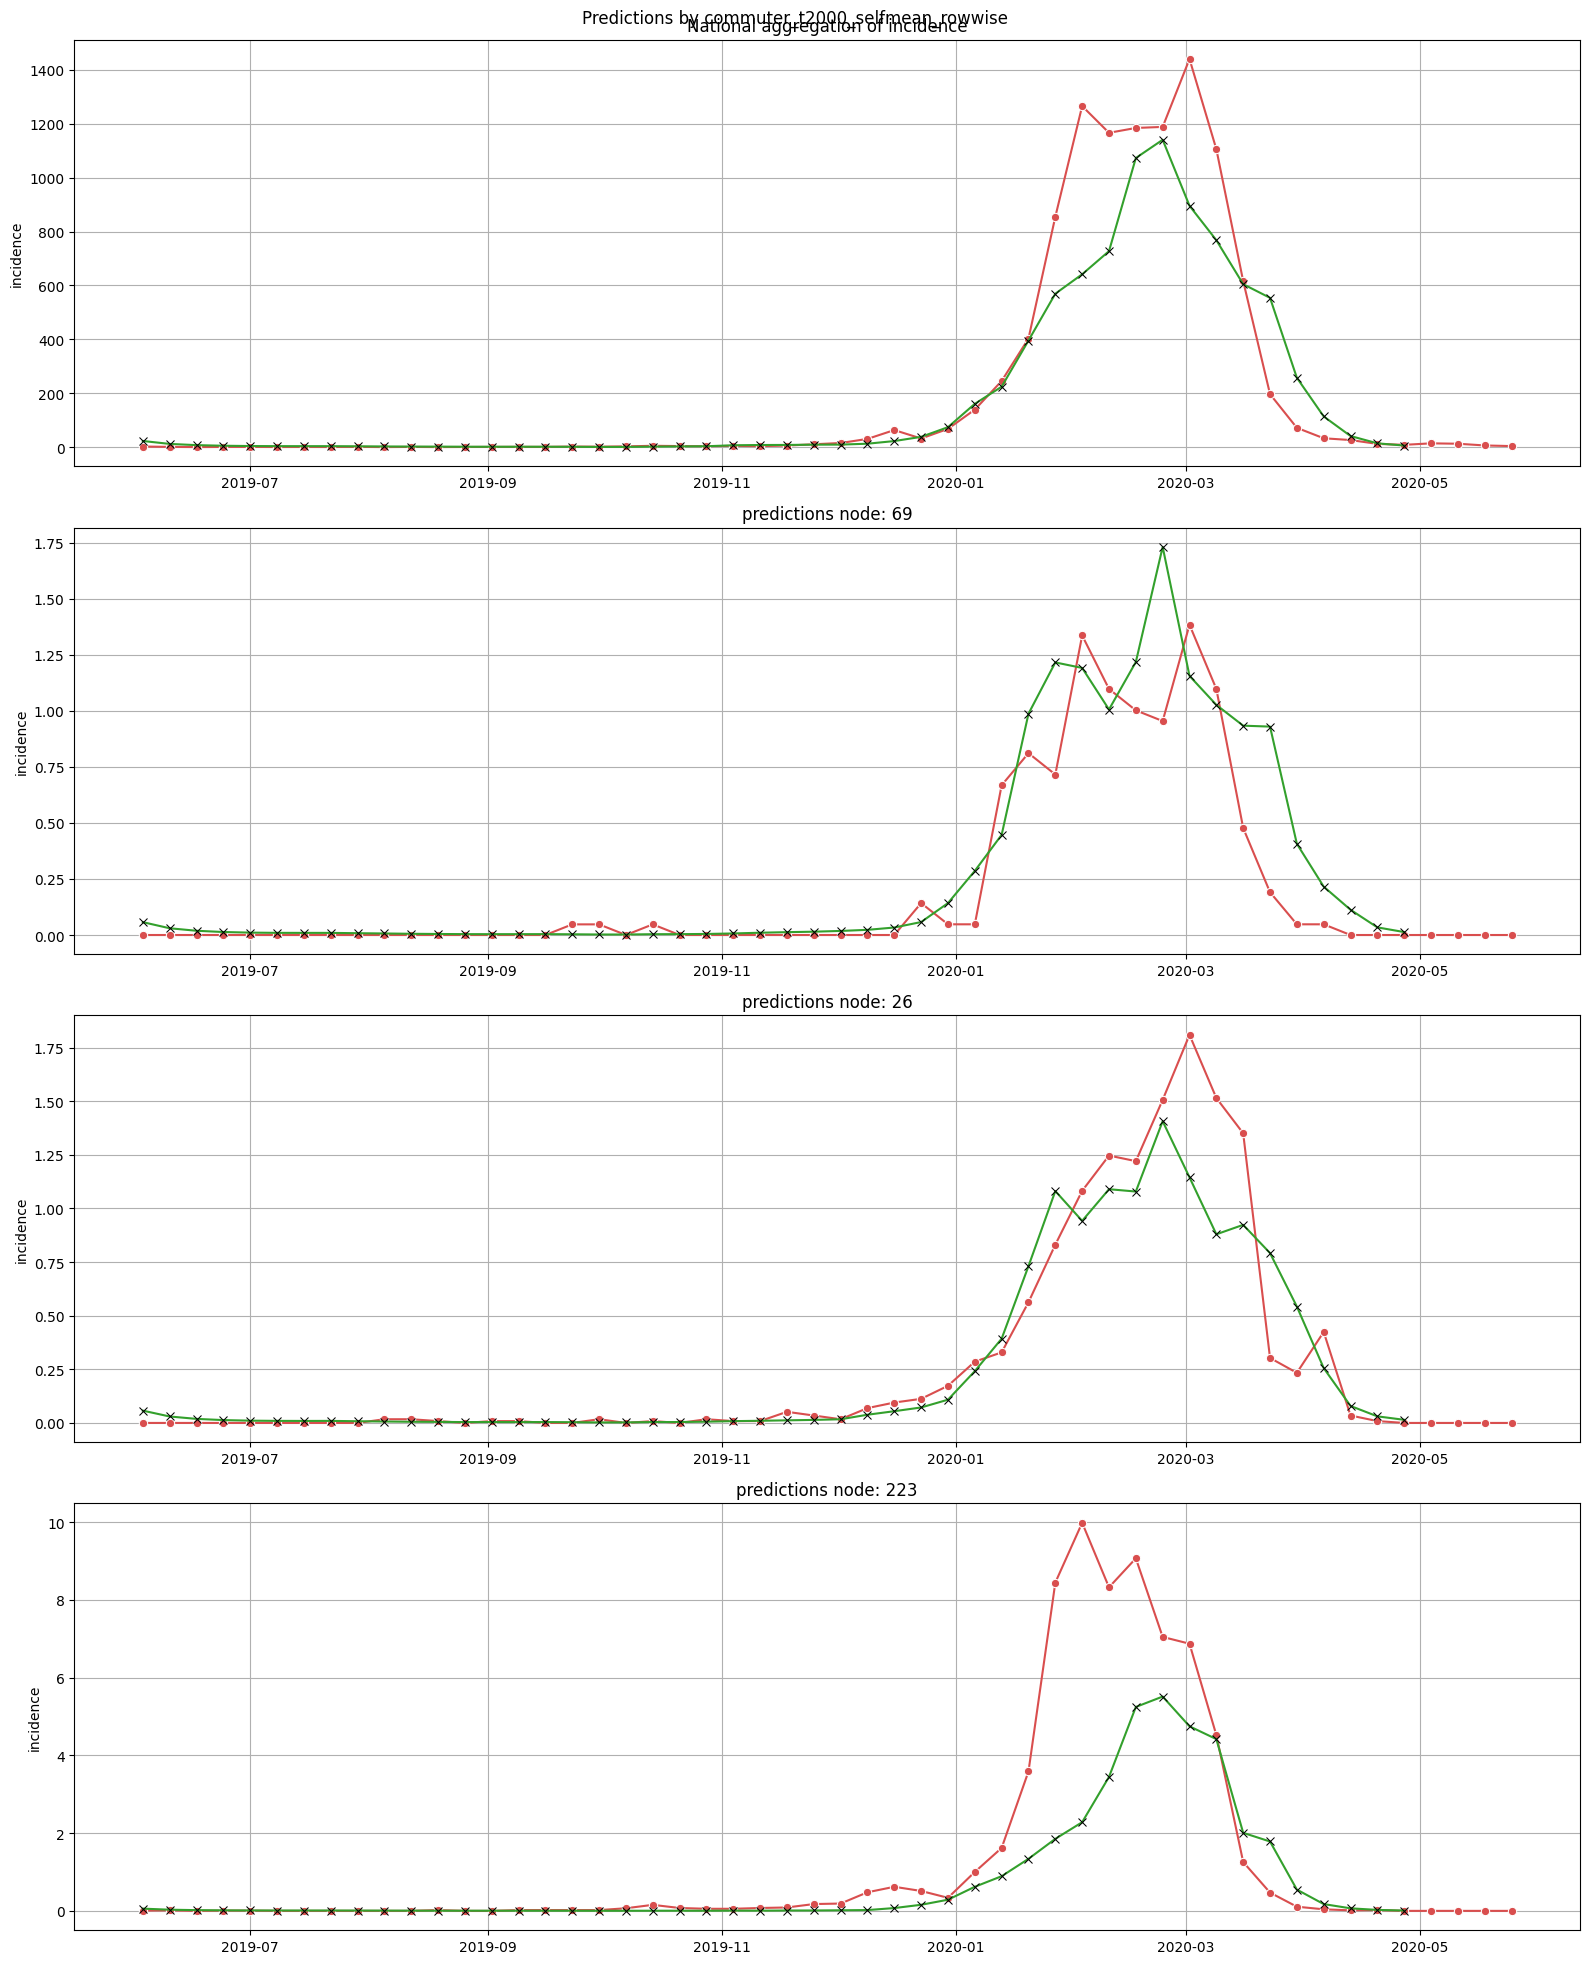

In [ ]:
commutermodel.show_forecasts('test',[69,26,223,15,280])

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>],
       dtype=object))

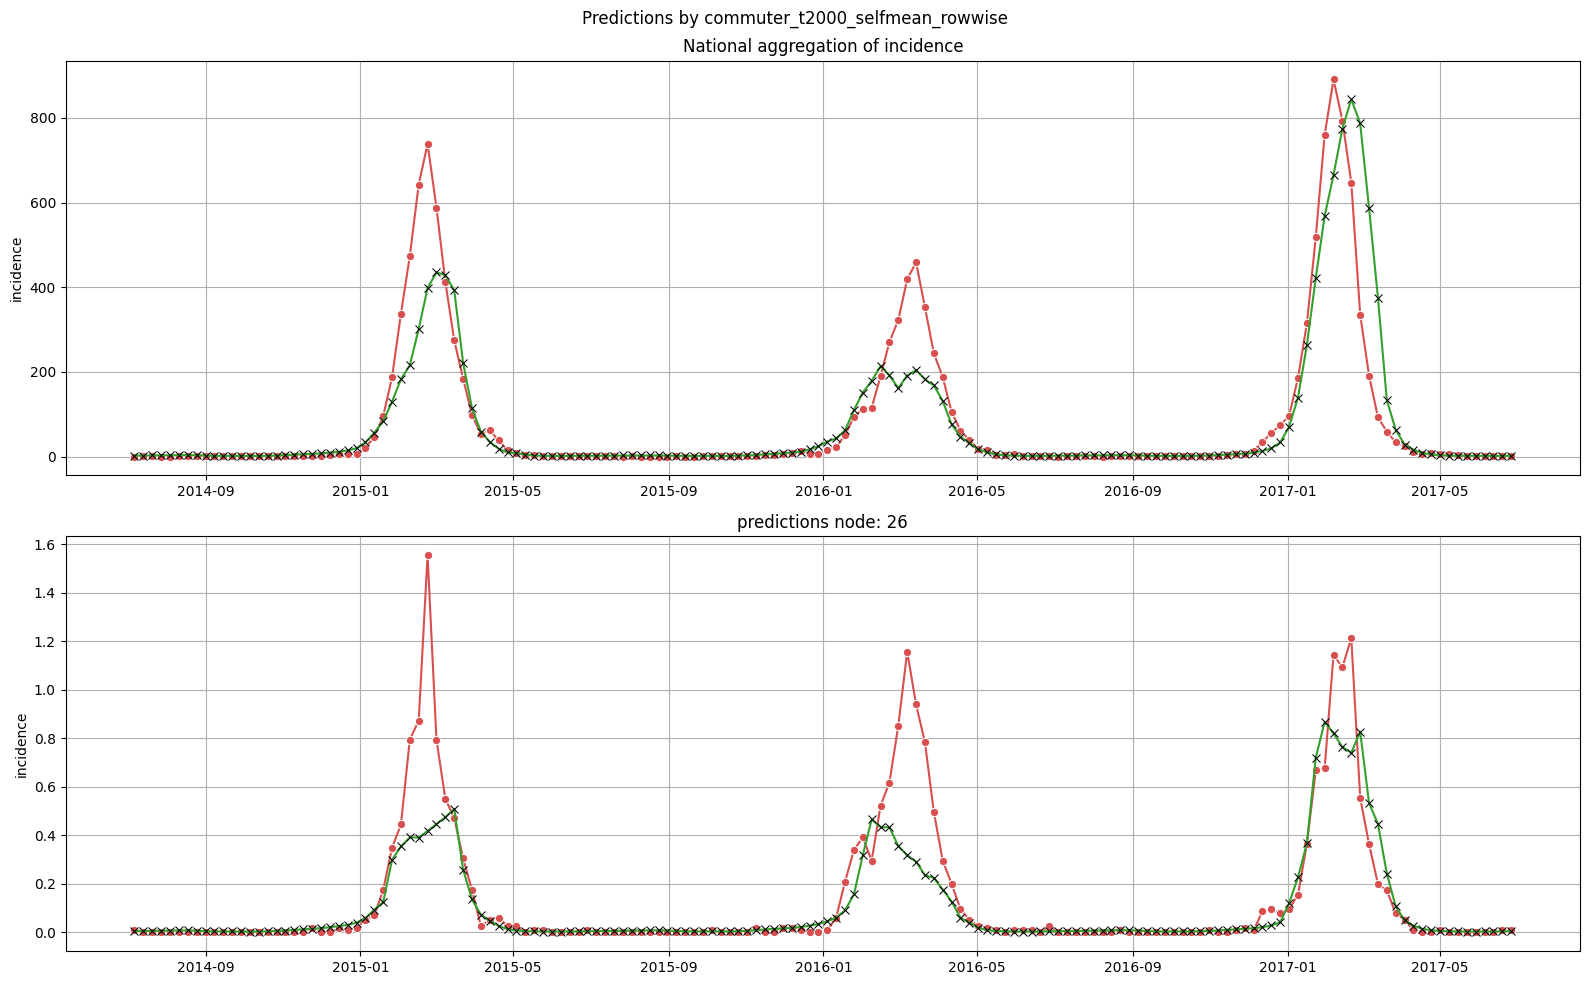

In [37]:
commutermodel.show_forecasts('train',26, timeframe = ['2014-07-01','2017-07-01'])